In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import files
uploaded = files.upload ()

Saving nigeriahealthfacilities.csv to nigeriahealthfacilities.csv


In [3]:
print (uploaded.keys())

dict_keys(['nigeriahealthfacilities.csv'])


In [4]:
df = pd.read_csv('nigeriahealthfacilities.csv')

In [5]:
df.head()

,id,name,global_id,alternate_name,functional_status,type,ward_code,category,timestamp,accessibility,lga_name,lga_code,state_code,state_name,FID
0,1,G R A Nursing Home,af719462-abfd-4f47-9dc3-0987164e75ac,Nursing Home,Unknown,Primary,12413,Primary Health Center,2020-07-04T13:49:18Z,NaN,Maiduguri,124,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
1,2,Gishili Health Center,a29b0328-d844-4358-b0ab-2e120b8fb30f,Nursing Home,Functional,Primary,12413,Primary Health Center,2020-07-04T13:49:18Z,Unknown,Maiduguri,124,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
2,3,Lehobi Primary Health Care,b685b769-5c83-4f83-a182-00e7e1b777d8,NaN,Partially Functional,Primary,10207,Primary Health Center,2020-07-04T13:49:18Z,NaN,Askira Uba,102,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
3,4,Dugja Idp Camp,78e64f7a-cbb8-4357-9e64-a7e502534527,Mandara Girau Dispensary,Not Functional,Primary,10503,Primary Health Center,2020-07-04T13:49:18Z,Unknown,Biu,105,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...
4,5,Kopa Maikudiri Dispensary,409c97ce-7490-4dc2-a8f8-2b8d53ad2b12,NaN,Partially Functional,Primary,10209,Dispensary,2020-07-04T13:49:18Z,Unknown,Askira Uba,102,BR,Borno,sv_health_facilities.fid--3185df38_17a314b4ee6...


In [6]:
df.shape

(46146, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46146 entries, 0 to 46145
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 46146 non-null  int64 
 1   name               46146 non-null  object
 2   global_id          46146 non-null  object
 3   alternate_name     4026 non-null   object
 4   functional_status  46146 non-null  object
 5   type               46146 non-null  object
 6   ward_code          46146 non-null  object
 7   category           46112 non-null  object
 8   timestamp          46146 non-null  object
 9   accessibility      134 non-null    object
 10  lga_name           46146 non-null  object
 11  lga_code           46146 non-null  int64 
 12  state_code         45020 non-null  object
 13  state_name         46146 non-null  object
 14  FID                46146 non-null  object
dtypes: int64(2), object(13)
memory usage: 5.3+ MB


In [8]:
df.isnull().sum()

,0
id,0
name,0
global_id,0
alternate_name,42120
functional_status,0
type,0
ward_code,0
category,34
timestamp,0
accessibility,46012


In [9]:
df.columns

Index(['id', 'name', 'global_id', 'alternate_name', 'functional_status',
       'type', 'ward_code', 'category', 'timestamp', 'accessibility',
       'lga_name', 'lga_code', 'state_code', 'state_name', 'FID'],
      dtype='object')

In [10]:
df.describe()

,id,lga_code
count,46146.000000,46146.000000
mean,23311.124236,15658.749187
std,13467.929371,11386.058136
min,1.000000,101.000000
25%,11632.250000,4016.000000
50%,23315.500000,16002.000000
75%,34995.750000,26013.000000
max,46608.000000,35016.000000


In [11]:
df = df.drop('accessibility',axis=1)

In [12]:
df.columns

Index(['id', 'name', 'global_id', 'alternate_name', 'functional_status',
       'type', 'ward_code', 'category', 'timestamp', 'lga_name', 'lga_code',
       'state_code', 'state_name', 'FID'],
      dtype='object')

In [13]:
df = df.drop('alternate_name',axis=1)

In [14]:
df.columns

Index(['id', 'name', 'global_id', 'functional_status', 'type', 'ward_code',
       'category', 'timestamp', 'lga_name', 'lga_code', 'state_code',
       'state_name', 'FID'],
      dtype='object')

In [15]:
df = df.dropna(subset=['category'])
df = df.dropna(subset=['state_code'])

In [16]:
print (df.isnull().sum())
print (df.shape)

id                   0
name                 0
global_id            0
functional_status    0
type                 0
ward_code            0
category             0
timestamp            0
lga_name             0
lga_code             0
state_code           0
state_name           0
FID                  0
dtype: int64
(44986, 13)


In [17]:
df['state_name'].value_counts()

,count
state_name,
Lagos,2320
Katsina,2228
Benue,2192
Niger,2010
Ogun,1721
Oyo,1713
Imo,1661
Anambra,1648
Osun,1607


In [18]:
df['state_name'].nunique()

36

In [19]:
df['functional_status'].value_counts()

,count
functional_status,
Functional,33330
Unknown,11549
Not Functional,100
Partially Functional,7


In [20]:
df['category'].value_counts()

,count
category,
Primary Health Center,27057
Dispensary,8601
Maternity Home,4393
Private Non Profit,1131
Medical Center,941
Specialist Hospital,669
General Hospital,618
Comprehensive Health Center,455
Educational Clinic,245


In [21]:
df['state_name'].value_counts().head(10)

,count
state_name,
Lagos,2320
Katsina,2228
Benue,2192
Niger,2010
Ogun,1721
Oyo,1713
Imo,1661
Anambra,1648
Osun,1607


In [22]:
df['state_name'].value_counts().tail(10)

,count
state_name,
Kwara,891
Akwa Ibom,870
Borno,850
Gombe,776
Jigawa,729
Rivers,723
Ekiti,679
Yobe,597
Fct,576


In [23]:
top10 = df['state_name'].value_counts().head(10)

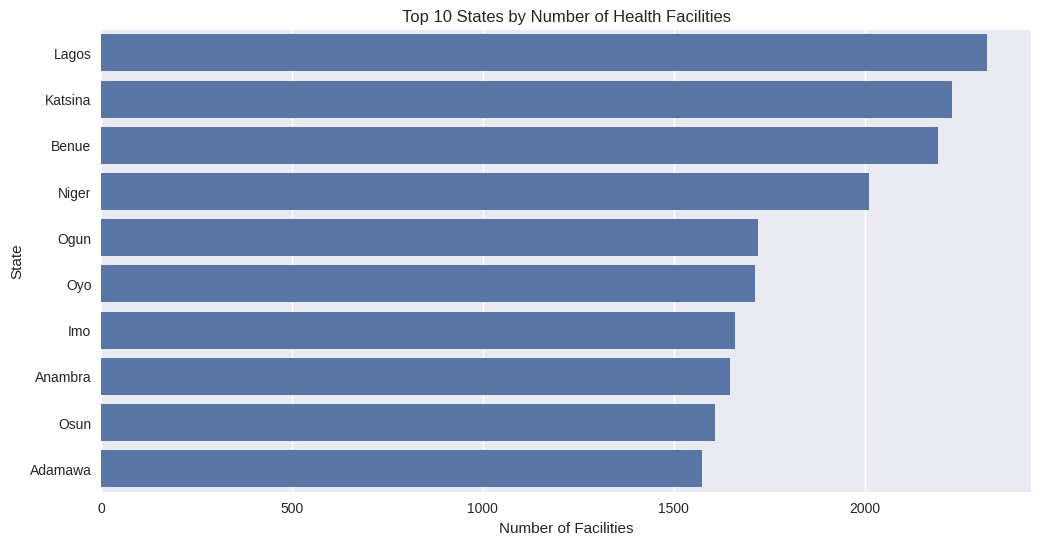

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title('Top 10 States by Number of Health Facilities')
plt.xlabel('Number of Facilities')
plt.ylabel('State')
plt.savefig('top10_states_health_facilities.png')
plt.show()

In [25]:
bottom10 = df['state_name'].value_counts().tail(10)

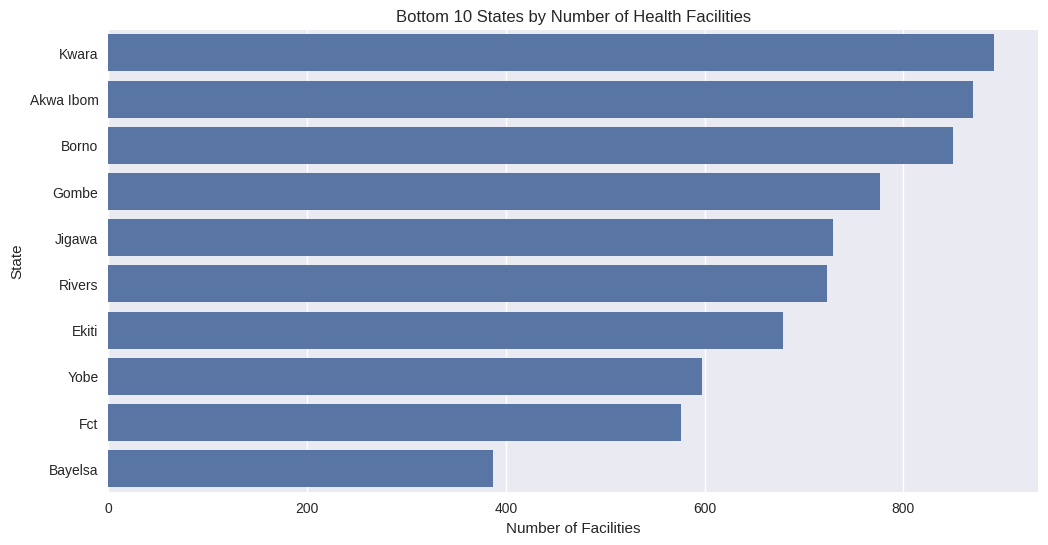

In [26]:
plt.figure(figsize=(12,6))
sns.barplot(x=bottom10.values, y=bottom10.index)
plt.title('Bottom 10 States by Number of Health Facilities')
plt.xlabel('Number of Facilities')
plt.ylabel('State')
plt.savefig('Bottom10_states_health_facilities.png')
plt.show()

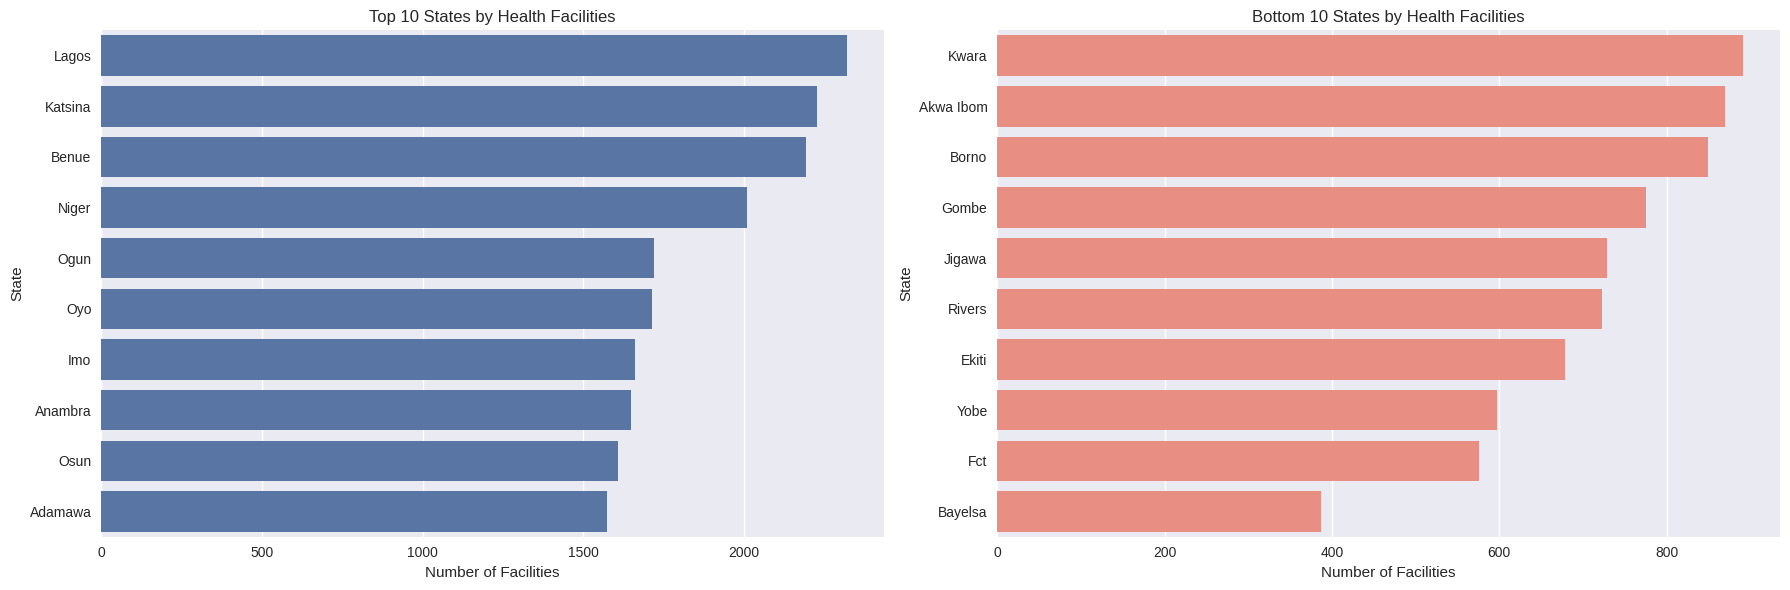

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=top10.values, y=top10.index, ax=ax1)
ax1.set_title('Top 10 States by Health Facilities')
ax1.set_xlabel('Number of Facilities')
ax1.set_ylabel('State')

sns.barplot(x=bottom10.values, y=bottom10.index, ax=ax2, color='salmon')
ax2.set_title('Bottom 10 States by Health Facilities')
ax2.set_xlabel('Number of Facilities')
ax2.set_ylabel('State')

plt.tight_layout()
plt.savefig('top10_vs_bottom10_states_health_facilities.png')
plt.show()

In [28]:
functional = df['functional_status'].value_counts()

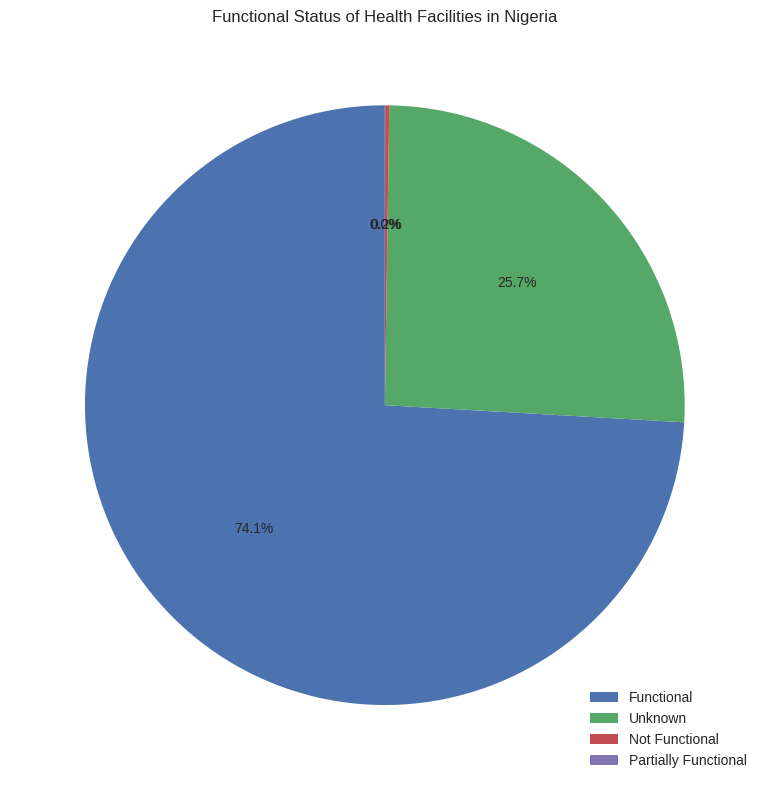

In [29]:
plt.figure(figsize=(10,8))
plt.pie(functional.values,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Functional Status of Health Facilities in Nigeria')
plt.legend(labels=functional.index, loc='lower right')
plt.tight_layout()
plt.savefig('functional_status_piechart.png')
plt.show()

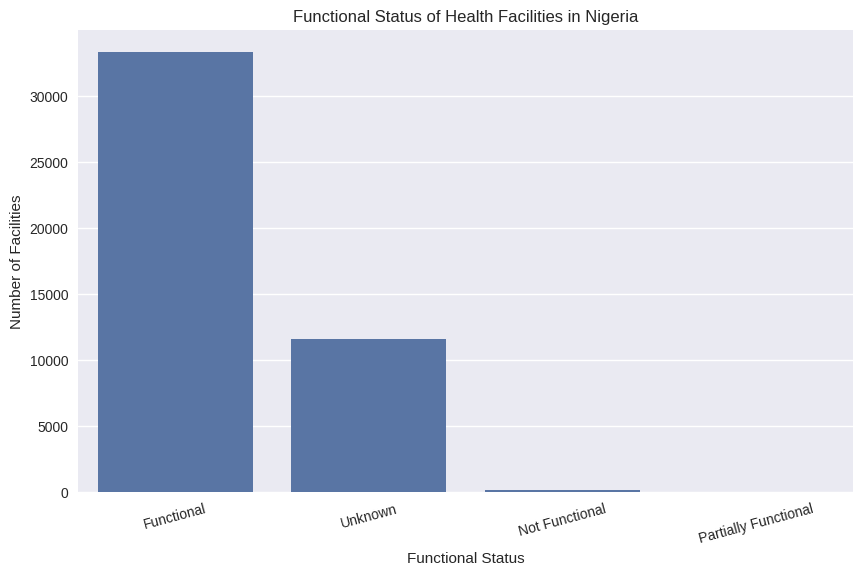

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=functional.index, y=functional.values)
plt.title('Functional Status of Health Facilities in Nigeria')
plt.xlabel('Functional Status')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=15)
plt.savefig('functional_status_barchart.png')
plt.show()

In [31]:
top10_category = df['category'].value_counts().head(10)

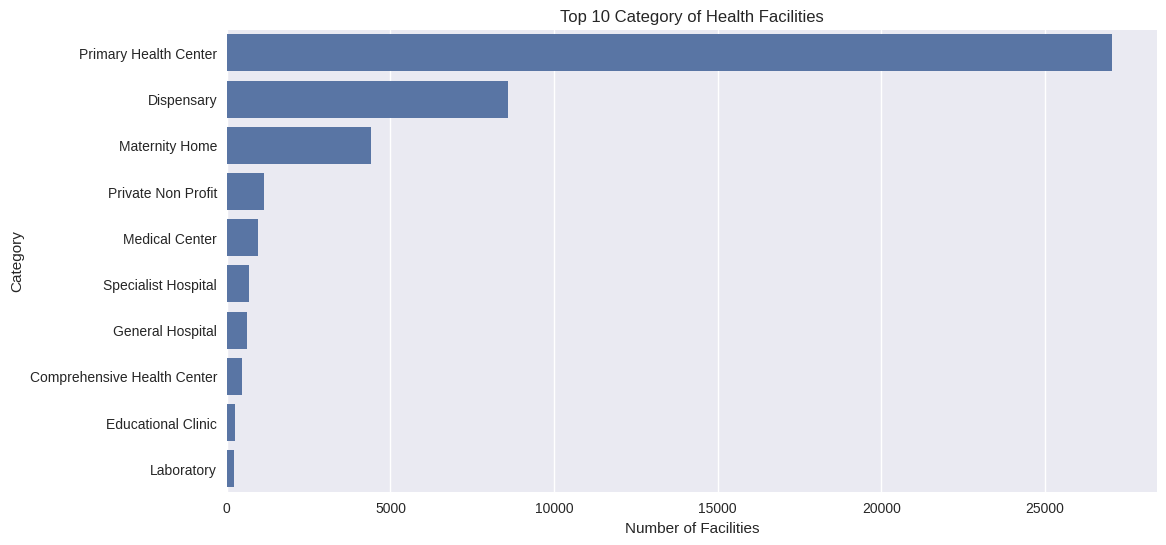

In [32]:
plt.figure(figsize=(12,6))
sns.barplot(x=top10_category.values, y=top10_category.index)
plt.title('Top 10 Category of Health Facilities')
plt.xlabel('Number of Facilities')
plt.ylabel('Category')
plt.savefig('top10_categories_health_facilities.png')
plt.show()

In [33]:
bottom5_category = df['category'].value_counts().tail(5)

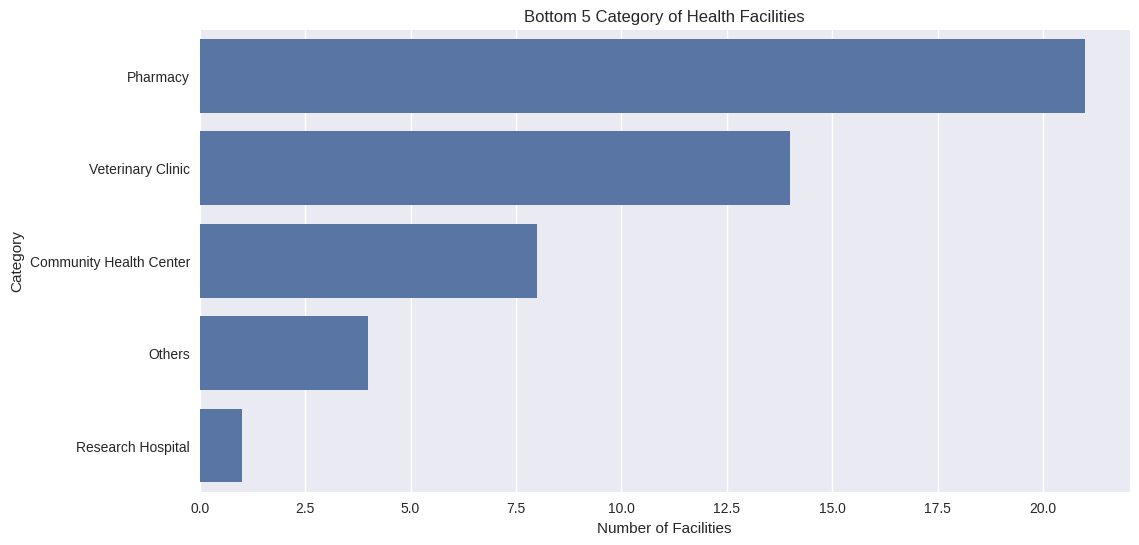

In [34]:
plt.figure(figsize=(12,6))
sns.barplot(x=bottom5_category.values, y=bottom5_category.index)
plt.title('Bottom 5 Category of Health Facilities')
plt.xlabel('Number of Facilities')
plt.ylabel('Category')
plt.savefig('bottom5_categories_health_facilities.png')
plt.show()

In [35]:
import os
print([f for f in os.listdir() if f.endswith('.png')])

['Bottom10_states_health_facilities.png', 'top10_categories_health_facilities.png', 'functional_status_piechart.png', 'top10_vs_bottom10_states_health_facilities.png', 'top10_states_health_facilities.png', 'functional_status_barchart.png', 'bottom5_categories_health_facilities.png']


In [36]:
from google.colab import files
import os

images = [f for f in os.listdir() if f.endswith('.png')]
for image in images:
    files.download(image)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>